# Decision Tree Model - EDA and Visualization

This notebook contains exploratory data analysis (EDA), score distribution boxplots, and Decision Tree model-related work for the student placement prediction project.

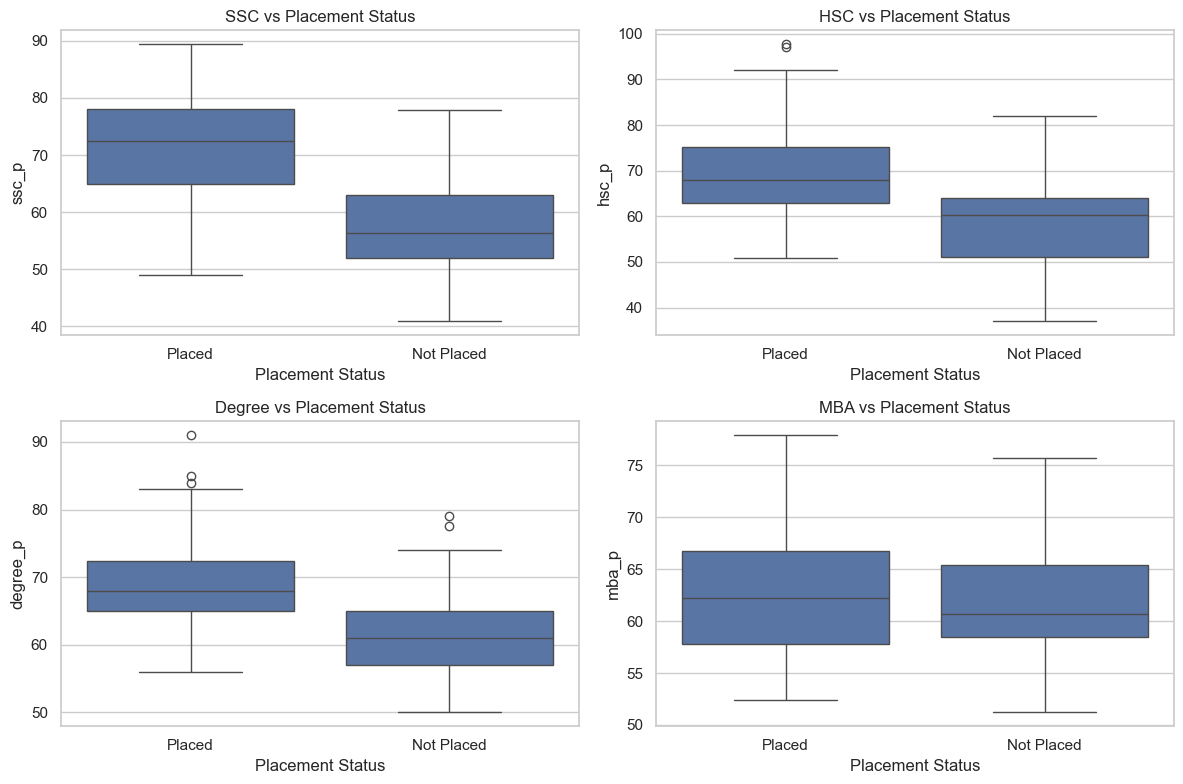

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df = pd.read_csv("../data/raw/Placement_Data_Full_Class.csv")

charts_dir = Path("../charts")
charts_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plots = [
    ("ssc_p", "SSC vs Placement Status"),
    ("hsc_p", "HSC vs Placement Status"),
    ("degree_p", "Degree vs Placement Status"),
    ("mba_p", "MBA vs Placement Status")
]

for ax, (column, title) in zip(axes.flatten(), plots):
    sns.boxplot(data=df, x="status", y=column, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Placement Status")

output_path = charts_dir / "decision_tree_boxplots.png"
plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches="tight")

# Show chart
plt.show()

---
## Decision Tree Model Training

Feature #4 & #5 — Train Decision Tree inside `imblearn.Pipeline` and evaluate using 4 metrics.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import joblib

print('All imports successful.')

In [ ]:
# ----- Data Loading & Cleaning (Feature #1) -----
DATA_PATH = '../data/raw/Placement_Data_Full_Class.csv'
df = pd.read_csv(DATA_PATH)

# Drop leakage columns
df = df.drop(columns=['sl_no', 'salary'])

# Encode target variable
df['status'] = df['status'].map({'Placed': 1, 'Not Placed': 0})

print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution:')
print(df['status'].value_counts())
df.head()

In [ ]:
# ----- Preprocessing Pipeline + SMOTE + Decision Tree (Feature #4) -----

# Separate features and target
X = df.drop(columns=['status'])
y = df['status']

# Identify column types
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print(f'Numerical columns: {num_cols}')
print(f'Categorical columns: {cat_cols}')

# Build ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

# Full Pipeline: Preprocessor + SMOTE + Decision Tree
dt_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)
print('\n Decision Tree trained successfully!')

In [ ]:
# ----- Model Evaluation (Feature #5) -----

y_pred = dt_pipeline.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('=' * 40)
print('   Decision Tree — Evaluation Results')
print('=' * 40)
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Placed', 'Placed']))

# Save results dict for later comparison (Feature #6 - Member 3 will use this)
dt_results = {
    'model': 'Decision Tree',
    'accuracy': round(acc, 4),
    'precision': round(prec, 4),
    'recall': round(rec, 4),
    'f1': round(f1, 4)
}
print('\nResults saved:', dt_results)

In [ ]:
# ----- Save Decision Tree Model -----

models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(dt_pipeline, models_dir / 'decision_tree_model.pkl')
print('Model saved to ../models/decision_tree_model.pkl')